In [1]:
import os
import sys
import numpy as np
import torch
import random
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

In [2]:
torch.cuda.is_available()

True

In [3]:
base_url = os.getcwd()
sys.path.append(base_url + '/Model')
sys.path.append(base_url + '/Util')

In [4]:
from feature_extractor import *
from domain_classifier import *
from task_classifier import *
from gradient_reversal import *

from Visualization import *
from DataPreprocess import *

# Intended Task

In [5]:
TASKS = ["Cross-Position", "Cross-Person", "Cross-Device"]
task = None
while True:
    print("1. Cross-Position\n2. Cross-Person\n3. Cross-Device")
    user_input = input("Please enter your task: ")
    if user_input == "1":
        task = "Cross-Position"
    elif user_input == "2":
        task = "Cross-Person"
    elif user_input == "3":
        task = "Cross-Device"
    if task in TASKS:
        break
    else:
        print("Invalid task. Please choose a valid task.")
print(f"Chosen task: {task}")

1. Cross-Position
2. Cross-Person
3. Cross-Device
Please enter your task: 1
Chosen task: Cross-Position


# Dataset

In [6]:
DATASETS = ["OPP", "DSADS", "PAMAP", "WISDM", "HHAR"]
dataset = None
if task == 'Cross-Position':
    while True:
        print("1. OPP\n2. DSADS\n3. PAMAP\n")
        user_input = input("Please enter your dataset: ")
        if user_input == "1":
            dataset = "OPP"
        elif user_input == "2":
            dataset = "DSADS"
        elif user_input == "3":
            dataset = "PAMAP"
        if dataset in DATASETS:
            break
        else:
            print("Invalid dataset. Please choose a valid dataset.")
elif task == 'Cross-Person':
    while True:
        print("1. OPP\n2. DSADS\n3. PAMAP\n4. WISDM\n")
        user_input = input("Please enter your dataset: ")
        if user_input == "1":
            dataset = "OPP"
        elif user_input == "2":
            dataset = "DSADS"
        elif user_input == "3":
            dataset = "PAMAP"
        elif user_input == "4":
            dataset = "WISDM"
        if dataset in DATASETS:
            break
        else:
            print("Invalid dataset. Please choose a valid dataset.")
print(f"Chosen dataset: {dataset}")

1. OPP
2. DSADS
3. PAMAP

Please enter your dataset: 2
Chosen dataset: DSADS


# Reproduciblitiy (Must Change Before Each Experiment)

In [7]:
os.environ["CUBLAS_WORKSPACE_CONFIG"]=":4096:8"

def set_seed(seed=42, loader=None):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    try:
        loader.sampler.generator.manual_seed(seed)
    except AttributeError:
        pass

seeds = [0, 42, 123]
seed = seeds[1] # Change this
set_seed(seed=seed)

# Hyper-parameters

In [8]:
lr = 0.0001
N_EPOCH = 20
beta1 = 0.9
beta2 = 0.99
lr_domain_mult = 1
batch_size = 32

In [9]:
# All of these have to taken input from shell script
win_size = 128
overlap = 0.

if task == "Cross-Position":
    if dataset == "DSADS":
        domains = {0:"TORSO", 1:"RA", 2:"LA", 3:"RL", 4:"LL"}
        sources = [0, 2, 3, 4]
        nsources = len(sources)
        target = 1
        activities = [ "standing", "lying-back", "ascending", "walking-parking-lot", "treadmill-running", "stepper-exercise", "cross-trainer-exercise", "rowing", "jumping",  "playing-basketball"]
        activity_num = len(activities)
        item = ["train","valid","test"]
        person_list = ["User1","User2","User3","User4", "User5","User6","User7","User8"]
        position_array = ["TORSO","RA","LA","RL","LL"]
    elif dataset == "OPP":
        domains = {0:"BACK", 1:"RUA", 2:"RLA", 3:"LUA", 4:"LLA"}
        sources = [1, 2, 3, 4]
        nsources = len(sources)
        target = 0
        activities = ['Sitting','Standing','Walking','Running']
        activity_num = len(activities)
        item = ["train","valid","test"]
        person_list = ["U1","U2","U3","U4"]
        position_array = ["BACK", "RUA", "RLA", "LUA","LLA"]
    elif dataset == "PAMAP":
        domains = {0:"Wrist", 1:"Chest", 2:"Ankle"}
        sources = [0, 2]
        nsources = len(sources)
        target = 1
        activities = ['ascending', 'lying', 'sitting', 'standing', 'walking', 'descending', 'vacuum', 'ironing', 'running', 'cycling', 'rope_jumping']
        activity_num = len(activities)
        item = ["train","valid","test"]
        person_list = ["U1","U2","U3","U4","U5","U6","U7","U8"]
        position_array = ['Wrist', 'Chest', 'Ankle']
        
elif task == "Cross-Person":
    if dataset == "DSADS":
        domains = {0:"User1", 1:"User2", 2:"User3", 3:"User4", 4:"User5", 5:"User6", 6:"User7", 7:"User8"}
        sources = [4, 5, 6, 7]
        target = [0, 1, 2, 3]
        nsources = len(sources)
        position_list = ["TORSO", "RA", "LA", "RL", "LL"]
        activities = [ "standing", "lying-back", "ascending", "walking-parking-lot", "treadmill-running", "stepper-exercise", "cross-trainer-exercise", "rowing", "jumping",  "playing-basketball"]
        activity_num = len(activities)
        item = ["train","valid","test"]
        person_array = ["User1","User2","User3","User4","User5","User6","User7","User8"]
    elif dataset == "OPP":
        domains = {0:"U1", 1:"U2", 2:"U3", 3:"U4"}
        sources = [0, 1]
        target = [2, 3]
        nsources = len(sources)
        position_list = ["BACK", "RUA", "RLA", "LUA","LLA"]
        activities = ['Sitting','Standing','Walking','Running']
        activity_num = len(activities)
        item = ["train","valid","test"]
        person_array = ["U1","U2","U3","U4"]
    elif dataset == "PAMAP":
        domains = {0:'U1', 1:'U2', 2:'U3', 3:'U4', 4:'U5', 5:'U6', 6:'U7', 7:'U8'}
        sources = [0, 1, 2, 3]
        nsources = len(sources)
        target = [4, 5, 6, 7]
        activities = ['ascending', 'lying', 'sitting', 'standing', 'walking', 'descending', 'vacuum', 'ironing', 'running', 'cycling', 'rope_jumping']
        activity_num = len(activities)
        item = ["train","valid","test"]
        position_list = ['Wrist', 'Chest', 'Ankle']
        person_array = ["U1","U2","U3","U4","U5","U6","U7","U8"]
elif task == "Cross-Device":
    pass

print(activity_num)

10


In [10]:
if overlap == 0.0:
    step_size = win_size
else:
    step_size=int(win_size*(1-overlap))
gpu_id= 0
DEVICE = torch.device('cuda:'+str(gpu_id) if torch.cuda.is_available() else 'cpu')

In [11]:
if dataset == "DSADS":
    AXIS = 3
    FROM = 0
    TO = FROM+3
    START = 4
    END = 5
elif dataset == "OPP":
    AXIS = 3
    FROM = 0
    TO = FROM+3
    START = 3
    END = 4
elif dataset == "PAMAP":
    AXIS = 3
    FROM = 0
    TO = FROM+3
    START = 4
    END = 5

In [12]:
if task == "Cross-Position":
    if dataset == "DSADS":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(int(overlap))
        dataset_path = base_url + "/Dataset_Preprocessed/DSADS/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/DSADS-Cross-Position-Heterogeneity/"+folder_name+"/Target-Position-" + position_array[target] + '/seed' + str(seed) + "/"
        main_folder = "DSADS-AllPerson-DifferentPosition"
    elif dataset == "OPP":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(int(overlap))
        dataset_path = base_url + "/Dataset_Preprocessed/OPPORTUNITY/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/OPP-Cross-Position-Heterogeneity/"+folder_name+"/Target-Position-" + position_array[target] + '/seed' + str(seed) + "/"
        main_folder = "OPP-AllPerson-DifferentPosition"
    elif dataset == "PAMAP":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(int(overlap))
        dataset_path = base_url + "/Dataset_Preprocessed/PAMAP/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/PAMAP-Cross-Position-Heterogeneity/"+folder_name+"/Target-Position-" + position_array[target] + '/seed' + str(seed) + "/"
        main_folder = "PAMAP-AllPerson-DifferentPosition"
        
elif task == "Cross-Person":
    target_string = "_".join([domains[i] for i in target])
    if dataset == "DSADS":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(int(overlap))
        dataset_path = base_url + "/Dataset_Preprocessed/DSADS/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/DSADS-Cross-Person-Heterogeneity/"+folder_name+"/Target-" + target_string + '/seed' + str(seed) + "/"
        main_folder = "DSADS-SamePosition-DifferentPerson"
    elif dataset == "OPP":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(int(overlap))
        dataset_path = base_url + "/Dataset_Preprocessed/OPPORTUNITY/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/OPP-Cross-Person-Heterogeneity/"+folder_name+"/Target-" + target_string + '/seed' + str(seed) + "/"
        main_folder = "OPP-SamePosition-DifferentPerson"
    elif dataset == "PAMAP":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(int(overlap))
        dataset_path = base_url + "/Dataset_Preprocessed/PAMAP/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/PAMAP-Cross-Person-Heterogeneity/"+folder_name+"/Target-" + target_string + '/seed' + str(seed) + "/"
        main_folder = "PAMAP-AllPerson-DifferentPerson"

if not os.path.exists(save_path):
    os.makedirs(save_path)

In [13]:
# Recalculate the Batch size. Batch size should be divisible by the number of domains
# Because one batch of data contains equal amount of data from all the domains.
# number of domains = nsources + 1 (target)
data_per_batch = batch_size//(nsources+1)
batch_size = data_per_batch * (nsources+1)

In [14]:
s_train = [[] for _ in range(nsources)]
t_train = []

s_gt_train = [[] for _ in range(nsources)]
t_gt_train = []

#===================================================#

s_valid = [[] for _ in range(nsources)]
t_valid = []

s_gt_valid = [[] for _ in range(nsources)]
t_gt_valid = []

#===================================================#

s_test = [[] for _ in range(nsources)]
t_test = []

s_gt_test = [[] for _ in range(nsources)]
t_gt_test = []

In [15]:
# sources can be [0, 1, 3, 4], and target = 2
if task == 'Cross-Position':
    print('Source')
    for i in range(len(sources)):
        # Create an empty DataFrame to hold the aggregated data for this source position
        df_aggregated_train = pd.DataFrame()
        df_aggregated_valid = pd.DataFrame()
        df_aggregated_test = pd.DataFrame()

        # Combine data from all users for the current source position
        for person in person_list:
            for split_index in range(0, 3):
                file_name = person + "_" + position_array[sources[i]] + '_' + item[split_index]
                print(f"Processing: {file_name}")
                df = pd.read_csv(dataset_path + file_name + '.csv', sep=",")
                
                # Aggregate data into the corresponding split DataFrame
                if split_index == 0:
                    df_aggregated_train = pd.concat([df_aggregated_train, df], ignore_index=True)
                elif split_index == 1:
                    df_aggregated_valid = pd.concat([df_aggregated_valid, df], ignore_index=True)
                elif split_index == 2:
                    df_aggregated_test = pd.concat([df_aggregated_test, df], ignore_index=True)
        
        # Pass the aggregated data to calculate_window
        calculate_window(df_aggregated_train, s_train[i], s_gt_train[i], win_size, step_size, FROM, TO, START, END, AXIS)
        calculate_window(df_aggregated_valid, s_valid[i], s_gt_valid[i], win_size, step_size, FROM, TO, START, END, AXIS)
        calculate_window(df_aggregated_test, s_test[i], s_gt_test[i], win_size, step_size, FROM, TO, START, END, AXIS)

    # For the target position, similarly aggregate data across all users
    df_aggregated_train_target = pd.DataFrame()
    df_aggregated_valid_target = pd.DataFrame()
    df_aggregated_test_target = pd.DataFrame()
    
    print('Target')
    for person in person_list:
        for split_index in range(0, 3):
            file_name = person + "_" + position_array[target] + '_' + item[split_index]
            print(f"Processing: {file_name}")
            df = pd.read_csv(dataset_path + file_name + '.csv', sep=",")
            
            if split_index == 0:
                df_aggregated_train_target = pd.concat([df_aggregated_train_target, df], ignore_index=True)
            elif split_index == 1:
                df_aggregated_valid_target = pd.concat([df_aggregated_valid_target, df], ignore_index=True)
            elif split_index == 2:
                df_aggregated_test_target = pd.concat([df_aggregated_test_target, df], ignore_index=True)

    calculate_window(df_aggregated_train_target, t_train, t_gt_train, win_size, step_size, FROM, TO, START, END, AXIS)
    calculate_window(df_aggregated_valid_target, t_valid, t_gt_valid, win_size, step_size, FROM, TO, START, END, AXIS)
    calculate_window(df_aggregated_test_target, t_test, t_gt_test, win_size, step_size, FROM, TO, START, END, AXIS)
    
elif task == 'Cross-Person':
    for i in range(len(sources)):
        # Create an empty DataFrame to hold the aggregated data for this source position
        df_aggregated_train = pd.DataFrame()
        df_aggregated_valid = pd.DataFrame()
        df_aggregated_test = pd.DataFrame()
        
        for position in position_list:
            for split_index in range(0, 3):
                file_name = person_array[sources[i]] + "_" + position + '_' + item[split_index]
                print(f"Processing: {file_name}")
                df = pd.read_csv(dataset_path + file_name + '.csv', sep=",")
                
                # Aggregate data into the corresponding split DataFrame
                if split_index == 0:
                    df_aggregated_train = pd.concat([df_aggregated_train, df], ignore_index=True)
                elif split_index == 1:
                    df_aggregated_valid = pd.concat([df_aggregated_valid, df], ignore_index=True)
                elif split_index == 2:
                    df_aggregated_test = pd.concat([df_aggregated_test, df], ignore_index=True)
        
        # Pass the aggregated data to calculate_window
        calculate_window(df_aggregated_train, s_train[i], s_gt_train[i], win_size, step_size, FROM, TO, START, END, AXIS)
        calculate_window(df_aggregated_valid, s_valid[i], s_gt_valid[i], win_size, step_size, FROM, TO, START, END, AXIS)
        calculate_window(df_aggregated_test, s_test[i], s_gt_test[i], win_size, step_size, FROM, TO, START, END, AXIS)

    # For the target position, similarly aggregate data across all users
    
    for i in range(len(target)):
        df_aggregated_train_target = pd.DataFrame()
        df_aggregated_valid_target = pd.DataFrame()
        df_aggregated_test_target = pd.DataFrame()
        
        for position in position_list:
            for split_index in range(0, 3):
                file_name = person_array[target[i]] + "_" + position + '_' + item[split_index]
                print(f"Processing: {file_name}")
                df = pd.read_csv(dataset_path + file_name + '.csv', sep=",")

                if split_index == 0:
                    df_aggregated_train_target = pd.concat([df_aggregated_train_target, df], ignore_index=True)
                elif split_index == 1:
                    df_aggregated_valid_target = pd.concat([df_aggregated_valid_target, df], ignore_index=True)
                elif split_index == 2:
                    df_aggregated_test_target = pd.concat([df_aggregated_test_target, df], ignore_index=True)

        calculate_window(df_aggregated_train_target, t_train, t_gt_train, win_size, step_size, FROM, TO, START, END, AXIS)
        calculate_window(df_aggregated_valid_target, t_valid, t_gt_valid, win_size, step_size, FROM, TO, START, END, AXIS)
        calculate_window(df_aggregated_test_target, t_test, t_gt_test, win_size, step_size, FROM, TO, START, END, AXIS)

elif task == "Cross-Device":
    pass

Source
Processing: User1_RA_train
Processing: User1_RA_valid
Processing: User1_RA_test
Processing: User2_RA_train
Processing: User2_RA_valid
Processing: User2_RA_test
Processing: User3_RA_train
Processing: User3_RA_valid
Processing: User3_RA_test
Processing: User4_RA_train
Processing: User4_RA_valid
Processing: User4_RA_test
Processing: User5_RA_train
Processing: User5_RA_valid
Processing: User5_RA_test
Processing: User6_RA_train
Processing: User6_RA_valid
Processing: User6_RA_test
Processing: User7_RA_train
Processing: User7_RA_valid
Processing: User7_RA_test
Processing: User8_RA_train
Processing: User8_RA_valid
Processing: User8_RA_test
Processing: User1_LA_train
Processing: User1_LA_valid
Processing: User1_LA_test
Processing: User2_LA_train
Processing: User2_LA_valid
Processing: User2_LA_test
Processing: User3_LA_train
Processing: User3_LA_valid
Processing: User3_LA_test
Processing: User4_LA_train
Processing: User4_LA_valid
Processing: User4_LA_test
Processing: User5_LA_train
Proces

In [16]:
# Number of rows or number of training domains (different positions)
len(s_train)

4

In [17]:
flattened_arrays = [np.concatenate(row) for row in s_train]
s_train = np.array(flattened_arrays).astype(np.float32)

In [18]:
print(s_train.shape)

(4, 2812, 128, 1, 3)


In [19]:
s_gt_train = np.array(s_gt_train).astype(np.float32)

In [20]:
print(s_gt_train.shape)

(4, 2812)


In [21]:
# sources:
flattened_arrays = [np.concatenate(row) for row in s_valid]
s_valid = np.array(flattened_arrays).astype(np.float32)
s_gt_valid = np.array(s_gt_valid).astype(np.float32)

flattened_arrays = [np.concatenate(row) for row in s_test]
s_test = np.array(flattened_arrays).astype(np.float32)
s_gt_test = np.array(s_gt_test).astype(np.float32)

#======================================================================

#Target:
t_train = np.concatenate(t_train, axis=0).astype(np.float32)
t_gt_train = np.array(t_gt_train).astype(np.float32)
t_valid = np.concatenate(t_valid, axis=0).astype(np.float32)
t_gt_valid = np.array(t_gt_valid).astype(np.float32)
t_test = np.concatenate(t_test, axis=0).astype(np.float32)
t_gt_test = np.array(t_gt_test).astype(np.float32)

In [22]:
# plot_training_data_distribution_multi_source(s_gt_train[0], s_gt_train[1], t_gt_train, activities, save_path)

In [23]:
# plot_training_data_distribution_multi_source(s_gt_train[1], s_gt_train[2], t_gt_train, activities, save_path)

In [24]:
# plot_training_data_distribution_multi_source(s_gt_train[2], s_gt_train[3], t_gt_train, activities, save_path)

In [25]:
output_gt_number = len(np.unique(s_gt_train[0]))
print(output_gt_number)

10


In [26]:
extractor = FeatureExtractor().to(DEVICE)
# number of domains number of source domains + target domain
dclassifier = DomainClassifier((nsources+1)).to(DEVICE)
tclassifier = TaskClassifier(output_gt_number).to(DEVICE)
print(extractor)

FeatureExtractor(
  (model): Sequential(
    (0): Conv1d(3, 128, kernel_size=(8,), stride=(1,), padding=(3,), bias=False)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(256, 128, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): AdaptiveAvgPool1d(output_size=1)
  )
)


In [27]:
S_train = [[] for _ in range(nsources)]
S_valid = [[] for _ in range(nsources)]
S_test = [[] for _ in range(nsources)]

T_train = []
T_valid = []
T_test = []

for i in range(nsources):
    S_train[i], S_valid[i], S_test[i] = modified_load_train_valid_test(s_train[i], s_gt_train[i], s_valid[i], s_gt_valid[i], s_test[i], s_gt_test[i], data_per_batch)

T_train, T_valid, T_test = modified_load_train_valid_test(t_train, t_gt_train, t_valid, t_gt_valid, t_test, t_gt_test, data_per_batch)

In [28]:
# Initializing log
logfile = open(save_path + 'training_log.txt', 'w')

# each holds 1 batch of data from each source, for OPP it's 4 sources
# s: source, t: target
aug_s_sample = [0] * nsources
s_sample = [0] * nsources
s_label = [0] * nsources

criterion = nn.CrossEntropyLoss()

# Ground truth domain classifier tensors
d_true = [0] * (nsources+1)
k=0
for ith in sources:
    # d_true creates array according to the domain, eg. for domain 1, [1, 1, 1, 1, 1, ... len(batch_size)]
    d_true[k] = torch.full((data_per_batch,), ith).to(DEVICE).long()
    k+=1
# The last index is for the target domain
d_true[nsources] = torch.full((data_per_batch,), target).to(DEVICE).long()

S_train_itr_list = []
S_valid_itr_list = []
S_test_itr_list = []
        
for i in range(1, nsources):
    S_train_itr_list.append(iter(S_train[i]))
    S_valid_itr_list.append(iter(S_valid[i]))
    S_test_itr_list.append(iter(S_test[i]))

T_train_itr = iter(T_train)
T_valid_itr = iter(T_valid)
T_test_itr = iter(T_test)

"""DO NOT FORGET TO INITIALIZE THE OPTIMIZERS"""
param_list = list(extractor.parameters()) + list(tclassifier.parameters()) + list(dclassifier.parameters())
param_list2 = list(dclassifier.parameters())
optimizer = optim.Adam(params=param_list, lr=lr, betas=(beta1, beta2))
optimizer2 = optim.Adam(params=param_list2, lr=lr*lr_domain_mult, betas=(beta1, beta2))

task_train_acc_over_iter = []
dom_train_acc_over_iter = []

task_valid_acc_over_iter = []
dom_valid_acc_over_iter = []


"""============Include the Epoch loop here================"""
for e in range(N_EPOCH):
    extractor.train()
    tclassifier.train()
    dclassifier.train()

    task_correct, domain_correct = 0, 0
    task_total, domain_total = 0, 0
    task_loss_total, domain_loss_total = 0, 0

    # s_sample[i] is a batch of data, but not the ith batch.
    # For example, s_sample[0] will always hold 1 batch of data from the 1st source
    # in the next iteration next(....), s_sample[0] will hold the second batch of data for the 1st source.
    # n_batch --> number of batches per epoch
    # The following segment can possibly be replaced outside of the epoch
    n_batch = len(S_train[0].dataset) // batch_size
    total_steps = N_EPOCH * n_batch  # Adjust accordingly
    global_step = 0

    for index, (aug_s_sample[0], s_sample[0], s_label[0]) in enumerate(S_train[0]):           
        
        aug_s_sample[0], s_sample[0], s_label[0] = aug_s_sample[0].to(DEVICE).float(), s_sample[0].to(DEVICE).float(), s_label[0].to(DEVICE).long()
        for i in range(1, nsources):
            try:
                aug_s_sample[i], s_sample[i], s_label[i] = next(S_train_itr_list[i-1])
            except StopIteration:
                S_train_itr = iter(S_train[i])
                aug_s_sample[i], s_sample[i], s_label[i] = next(S_train_itr)
                
            aug_s_sample[i], s_sample[i], s_label[i] = aug_s_sample[i].to(DEVICE).float(), s_sample[i].to(DEVICE).float(), s_label[i].to(DEVICE).long()
        
        try:
            aug_t_sample, t_sample, t_label = next(T_train_itr)
        except StopIteration:
            T_train_itr = iter(T_train)
            aug_t_sample, t_sample, t_label = next(T_train_itr)
        
        aug_t_sample, t_sample = aug_t_sample.to(DEVICE).float(), t_sample.to(DEVICE).float()

        batch_sample_list = []
        batch_label_list = []
        batch_domain_list = []
        for i in range(0, nsources):
            batch_sample_list.append(s_sample[i])
            batch_label_list.append(s_label[i])
            batch_domain_list.append(d_true[i])
        batch_sample_list.append(t_sample)
        batch_domain_list.append(d_true[nsources])

        num_target_labels = len(t_label)
        # we assign activity_num to distinguish the target labels. As we only classify 0 to activity_num-1 tasks here.
        t_label = torch.full((num_target_labels,), activity_num).to(DEVICE).long()
        batch_label_list.append(t_label)

        batch_samples = torch.cat(batch_sample_list, dim=0)
        batch_labels = torch.cat(batch_label_list, dim=0)
        batch_domains = torch.cat(batch_domain_list, dim=0)
        
        # In a fixed format setting the model will not learn anything.
        # What torch.cat is doing is it's just stacking put domain[i+1]'s data over domain[i]
        # We need to shuffle the data
        # Generate random indices
        perm_indices = torch.randperm(batch_samples.size(0))
        # Shuffle tensors based on the generated indices
        batch_samples = batch_samples[perm_indices]
        batch_labels = batch_labels[perm_indices]
        batch_domains = batch_domains[perm_indices]
            
        # Forward Pass:
        # x represent total source + target, whereas, s represents soruce    
        x_feature = extractor(batch_samples)
        # label/task classifier, feeding x_feature, but we are only interested in the source labels
        s_pred_label = tclassifier(x_feature)

        # domain classifier
        lambda_value = dann_grl_schedule(total_steps)(global_step)
        grl = GradientReversalLayer.apply(x_feature, lambda_value)
        x_pred_domain = dclassifier(grl)
        x_pred_domain2 = dclassifier(grl.detach())
        
        # Before loss calculation we have to remove the target label related outputs.
        # nontarget is the list of indices related to source domains (non-target domain)
        nontarget = torch.where(batch_labels != activity_num)[0]
        true_labels = batch_labels[nontarget]
        pred_labels = s_pred_label[nontarget]

        # dLoss --> domain loss, tLoss --> task loss
        tLoss = criterion(pred_labels, true_labels)
        dLoss = criterion(x_pred_domain, batch_domains)
        dLoss2 = criterion(x_pred_domain2, batch_domains)
        total_loss = tLoss + dLoss

        optimizer.zero_grad()
        # Have to retain the computational graph because both task and domain classifier use
        # shared feature extractor parameters in their computational graph.
        
        # tLoss.backward(retain_graph=True)
        total_loss.backward()
        optimizer.step()
        
        optimizer2.zero_grad()
        dLoss2.backward()
        optimizer2.step()
        
        
        task_loss_total += tLoss.item()
        domain_loss_total += dLoss.item()

        task_total += pred_labels.size(0)
        domain_total += x_pred_domain.size(0)

        _, task_pred = torch.max(pred_labels.data, 1)
        _, domain_pred = torch.max(x_pred_domain, 1)
        task_correct += (task_pred == true_labels).sum()
        domain_correct += (domain_pred == batch_domains).sum()
        global_step+=1
        
        task_train_acc_over_iter.append(float(task_correct) * 100/ task_total)
        dom_train_acc_over_iter.append(float(domain_correct) * 100/ domain_total)
        
    task_acc_train = float(task_correct) * 100/ task_total
    domain_acc_train = float(domain_correct) * 100/ domain_total
    
    # task_train_acc_over_iter.append(task_acc_train)
    # dom_train_acc_over_iter.append(domain_acc_train)
    
    extractor.eval()
    tclassifier.eval()
    dclassifier.eval()
        
    """VALIDATION:"""
    with torch.no_grad():
        task_correct, domain_correct = 0, 0
        task_total, domain_total = 0, 0

        for valid_index, (aug_s_sample[0], s_sample[0], s_label[0]) in enumerate(S_valid[0]):
            aug_s_sample[0], s_sample[0], s_label[0] = aug_s_sample[0].to(DEVICE).float(), s_sample[0].to(DEVICE).float(), s_label[0].to(DEVICE).long()
            
            for i in range(1, nsources):
                try:
                    aug_s_sample[i], s_sample[i], s_label[i] = next(S_valid_itr_list[i-1])
                except StopIteration:
                    S_valid_itr = iter(S_valid[i])
                    aug_s_sample[i], s_sample[i], s_label[i] = next(S_valid_itr)    
                aug_s_sample[i], s_sample[i], s_label[i] = aug_s_sample[i].to(DEVICE).float(), s_sample[i].to(DEVICE).float(), s_label[i].to(DEVICE).long()
            
            try:
                aug_t_sample, t_sample, t_label = next(T_valid_itr)
            except StopIteration:
                T_valid_itr = iter(T_valid)
                aug_t_sample, t_sample, t_label = next(T_valid_itr)
            aug_t_sample, t_sample = aug_t_sample.to(DEVICE).float(), t_sample.to(DEVICE).float()

            batch_sample_list = []
            batch_label_list = []
            batch_domain_list = []
            for i in range(0, nsources):
                batch_sample_list.append(s_sample[i])
                batch_label_list.append(s_label[i])
                batch_domain_list.append(d_true[i])
            batch_sample_list.append(t_sample)
            batch_domain_list.append(d_true[nsources])

            num_target_labels = len(t_label)
            # we assign 10 to distinguish the target labels. As we only classify 4 tasks here.
            t_label = torch.full((num_target_labels,), 10).to(DEVICE).long()
            batch_label_list.append(t_label)

            batch_samples = torch.cat(batch_sample_list, dim=0)
            batch_labels = torch.cat(batch_label_list, dim=0)
            batch_domains = torch.cat(batch_domain_list, dim=0)
            
            # Generate random indices
            perm_indices = torch.randperm(batch_samples.size(0))

            # Shuffle tensors based on the generated indices
            batch_samples = batch_samples[perm_indices]
            batch_labels = batch_labels[perm_indices]
            batch_domains = batch_domains[perm_indices]
            
            x_feature = extractor(batch_samples)
            # label/task classifier, feeding x_feature, but we are only interested in the source labels
            s_pred_label = tclassifier(x_feature)

            # domain classifier
            grl = GradientReversalLayer.apply(x_feature, lambda_value)
            x_pred_domain = dclassifier(grl)

            nontarget = torch.where(batch_labels != 10)[0]
            true_labels = batch_labels[nontarget]
            pred_labels = s_pred_label[nontarget]

            task_total += pred_labels.size(0)
            domain_total += x_pred_domain.size(0)

            _, task_pred = torch.max(pred_labels.data, 1)
            _, domain_pred = torch.max(x_pred_domain, 1)
            task_correct += (task_pred == true_labels).sum()
            domain_correct += (domain_pred == batch_domains).sum()
            
            task_valid_acc_over_iter.append(float(task_correct) * 100/ task_total)
            dom_valid_acc_over_iter.append(float(domain_correct) * 100/ domain_total)

        task_acc_valid = float(task_correct) * 100/ task_total
        domain_acc_valid = float(domain_correct) * 100/ domain_total
        
        #task_train_acc_over_iter.append(task_acc_valid)
        #dom_train_acc_over_iter.append(domain_acc_valid)
        
        tqdm.tqdm.write('Epoch: [{}/{}], Task Train Acc: {:.2f}%, Domain Train Acc: {:.2f}%'.format(e + 1, N_EPOCH, task_acc_train, domain_acc_train))
        tqdm.tqdm.write('Epoch: [{}/{}], Task Valid Acc: {:.2f}%, Domain Valid Acc: {:.2f}%'.format(e + 1, N_EPOCH, task_acc_valid, domain_acc_valid))
        print("\n================================================================================\n")    
        
        torch.save(extractor.state_dict(), save_path + 'extractor.pth')
        torch.save(tclassifier.state_dict(), save_path + 'classifier.pth')
        torch.save(dclassifier.state_dict(), save_path + 'discriminator.pth')
        
        logfile.write('==========================================================\n')
        logfile.write(f'EPOCH: {e+1}')
        logfile.write(f'TRAIN_LOSS: {total_loss.item()}\n')
        logfile.write(f'DISCRIMINATOR_LOSS: {domain_loss_total}\n')
        logfile.write(f'TASK_LOSS: {task_loss_total}\n')
logfile.close()
# evaluation(e)

Epoch: [1/20], Task Train Acc: 57.17%, Domain Train Acc: 31.97%
Epoch: [1/20], Task Valid Acc: 67.04%, Domain Valid Acc: 25.79%


Epoch: [2/20], Task Train Acc: 71.85%, Domain Train Acc: 32.60%
Epoch: [2/20], Task Valid Acc: 79.06%, Domain Valid Acc: 31.86%


Epoch: [3/20], Task Train Acc: 78.73%, Domain Train Acc: 32.71%
Epoch: [3/20], Task Valid Acc: 84.96%, Domain Valid Acc: 32.29%


Epoch: [4/20], Task Train Acc: 83.14%, Domain Train Acc: 31.55%
Epoch: [4/20], Task Valid Acc: 87.31%, Domain Valid Acc: 33.80%


Epoch: [5/20], Task Train Acc: 86.32%, Domain Train Acc: 32.31%
Epoch: [5/20], Task Valid Acc: 89.42%, Domain Valid Acc: 34.42%


Epoch: [6/20], Task Train Acc: 87.91%, Domain Train Acc: 31.76%
Epoch: [6/20], Task Valid Acc: 90.01%, Domain Valid Acc: 31.86%


Epoch: [7/20], Task Train Acc: 89.48%, Domain Train Acc: 31.18%
Epoch: [7/20], Task Valid Acc: 93.22%, Domain Valid Acc: 31.56%


Epoch: [8/20], Task Train Acc: 90.66%, Domain Train Acc: 32.32%
Epoch: [8/20], Task Valid 

Evaluating....
Dataset: DSADS, all persons
Test_accuracy_target-TORSO: 42.68817204301075
Test_precision_target-TORSO: 0.4268817204301075
Test_recall_target-TORSO: 0.4268817204301075
Test_f1_target-TORSO: 0.4268817204301075


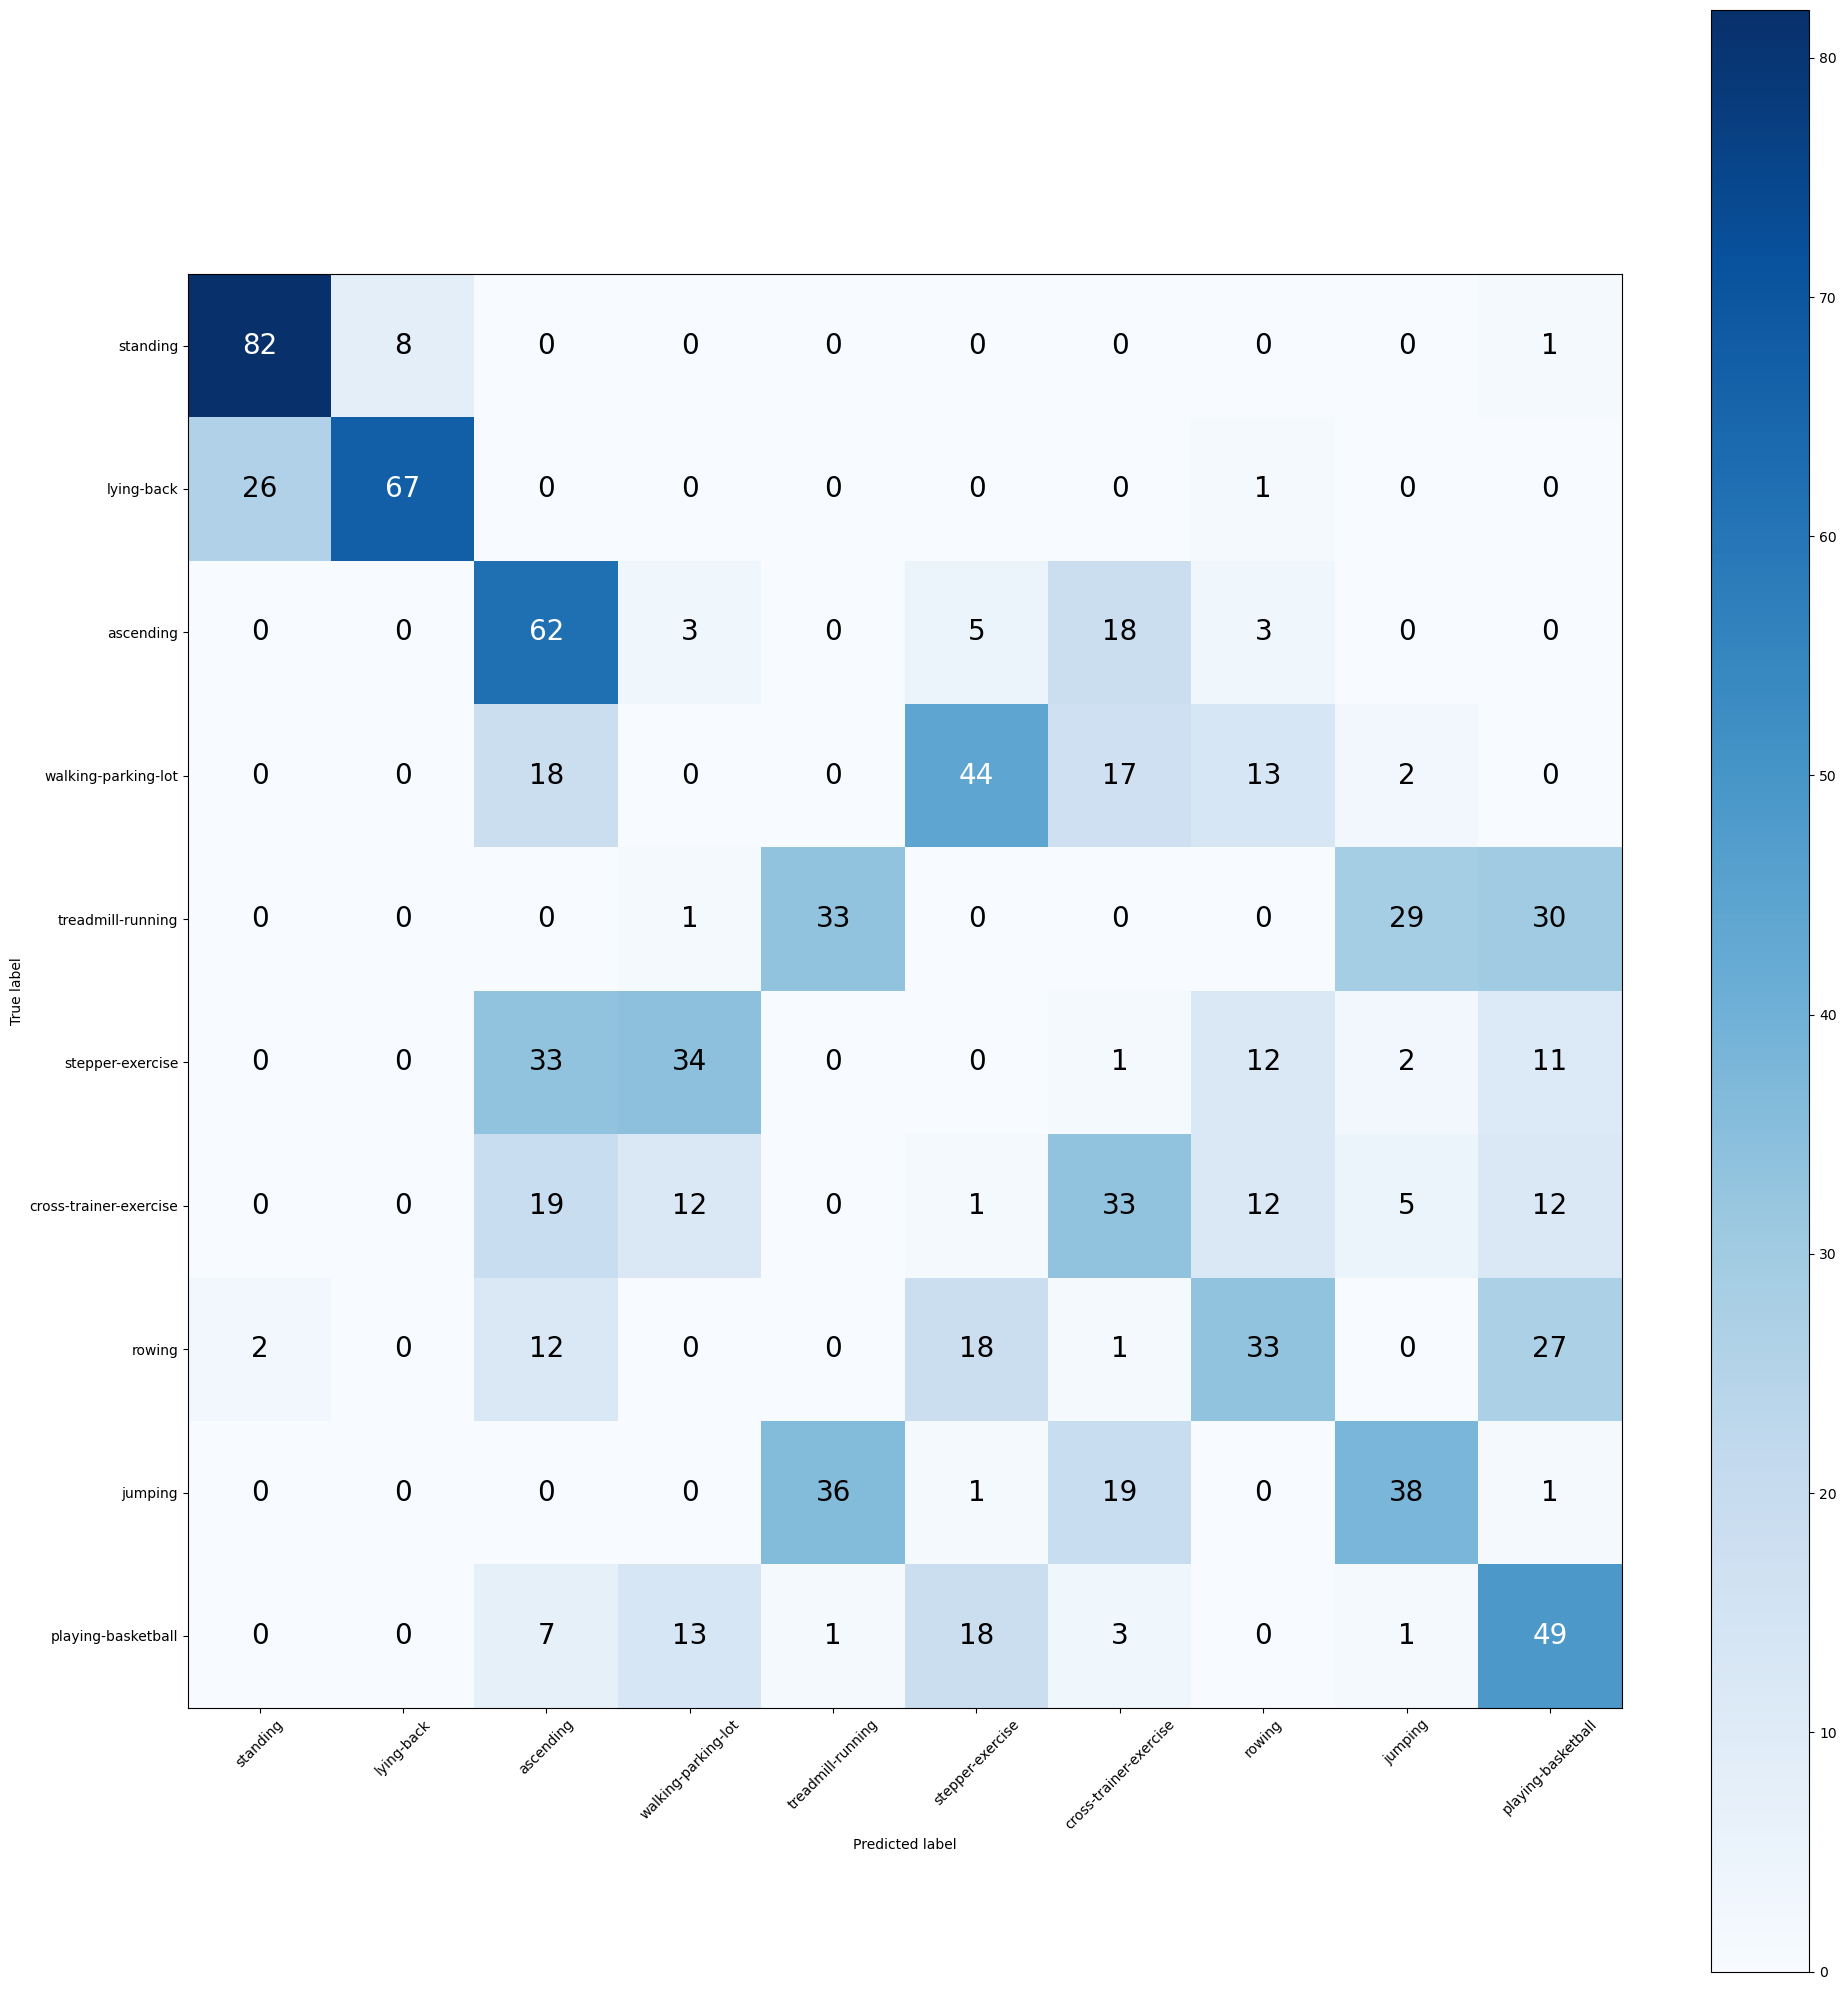

In [29]:
extractor = FeatureExtractor().to(DEVICE)
# number of domains number of source domains + target domain
dclassifier = DomainClassifier((nsources+1)).to(DEVICE)
tclassifier = TaskClassifier(output_gt_number).to(DEVICE)

extractor.load_state_dict(torch.load(save_path + 'extractor.pth'))
tclassifier.load_state_dict(torch.load(save_path + 'classifier.pth'))
dclassifier.load_state_dict(torch.load(save_path + 'discriminator.pth'))

t_test_sample = [0] * (nsources+1)
t_test_label = [0] * (nsources+1)
n_batch = len(T_test.dataset) // batch_size

t_test_total = 0
t_correct = 0
print("Evaluating....")

ground_truth = []
prediction = []

for b in range(n_batch):
    # now create a batch from test samples
    for i in range(nsources+1):
        try:
            _, t_test_sample[i], t_test_label[i] = next(T_test_itr)
        except StopIteration:
            T_test_itr = iter(T_test)
            _, t_test_sample[i], t_test_label[i] = next(T_test_itr)
        t_test_sample[i], t_test_label[i] = t_test_sample[i].to(DEVICE).float(), t_test_label[i].to(DEVICE).long()

    batch_samples = torch.cat(t_test_sample, dim=0)
    batch_labels = torch.cat(t_test_label, dim=0) 

    perm_indices = torch.randperm(batch_samples.size(0))
    # Shuffle tensors based on the generated indices
    batch_samples = batch_samples[perm_indices]
    true_labels = batch_labels[perm_indices]

    test_feature = extractor(batch_samples)
    test_pred_label = tclassifier(test_feature)

    _, predicted = torch.max(test_pred_label.data, 1)
    t_test_total += test_pred_label.size(0)
    t_correct += (predicted == true_labels).sum()

    ground_truth.extend(true_labels.cpu().numpy().tolist())
    prediction.extend(predicted.cpu().numpy().tolist())

t_test_acc = float(t_correct) * 100 / t_test_total

plt.figure(figsize=(20, 20))
plot_cm = confusion_matrix(ground_truth, prediction)
plot_confusion_matrix(plot_cm, classes=activities, title='Confusion_matrix', plot_save_path=save_path)

f1_micro        = f1_score(ground_truth,        prediction, average='micro')
precision_micro = precision_score(ground_truth, prediction, average='micro')
recall_micro    = recall_score(ground_truth,    prediction, average='micro')


all_sources = ""
for i in range(len(sources)):
    all_sources += domains[sources[i]] + " "


    
test_file = open(save_path + 'result.txt', "w")

if task == "Cross-Position":
        print(f"Dataset: {dataset}, all persons")
        print(f"Test_accuracy_target-{domains[target]}: {t_test_acc}")
        print(f"Test_precision_target-{domains[target]}: {precision_micro}")
        print(f"Test_recall_target-{domains[target]}: {recall_micro}")
        print(f"Test_f1_target-{domains[target]}: {f1_micro}")

        test_file.write(f"Dataset: {dataset}, all persons\n")
        test_file.write(f"Test_accuracy_target-{domains[target]}:{t_test_acc}\n")
        test_file.write(f"Test_precision_target-{domains[target]}:{precision_micro}\n")
        test_file.write(f"Test_recall_target-{domains[target]}:{recall_micro}\n")
        test_file.write(f"Test_f1_target-{domains[target]}:{f1_micro}\n")
        
elif task == "Cross-Person":
        target_string = ", ".join([domains[i] for i in target])
        print(f"Dataset: {dataset}, all Positions")
        print(f"Test_accuracy_target-({target_string}): {t_test_acc}")
        print(f"Test_precision_target-({target_string}): {precision_micro}")
        print(f"Test_recall_target-({target_string}): {recall_micro}")
        print(f"Test_f1_target-({target_string}): {f1_micro}")

        test_file.write(f"Dataset: {dataset}, all positions\n")
        test_file.write(f"Test_accuracy_target-({target_string}):{t_test_acc}\n")
        test_file.write(f"Test_precision_target-({target_string}):{precision_micro}\n")
        test_file.write(f"Test_recall_target-({target_string}):{recall_micro}\n")
        test_file.write(f"Test_f1_target-({target_string}):{f1_micro}\n")

test_file.close()

In [30]:
# evaluation(e)

In [31]:
# #Plotting the train and validation score over training iterations
# iterations = [i for i in range(1, len(task_train_acc_over_iter)+1)]
# plt.plot(iterations, task_train_acc_over_iter, label='Training-task', color='blue')
# plt.plot(iterations, dom_train_acc_over_iter, label='Training-domain', color='green')

# iterations = [i for i in range(1, len(task_valid_acc_over_iter)+1)]
# plt.plot(iterations, task_valid_acc_over_iter, label='Validation-task', color='orange')
# plt.plot(iterations, dom_valid_acc_over_iter, label='Validation-domain', color='red')

# # Adding labels and legend
# plt.xlabel('Training Iterations')
# plt.ylabel('Scores (accuracy)')
# plt.legend()
# filename = "OPP-source"
# for ith in sources:
#     filename += "-" + domains[ith]
# filename += ".png"
# plt.savefig(save_path + filename)
# # Display the plot
# plt.show()

In [32]:
# #Plotting the train and validation score over training iterations
# iterations = [i for i in range(1, len(task_train_acc_over_iter)+1)]
# plt.plot(iterations, task_train_acc_over_iter, label='Training-task', color='blue')
# plt.plot(iterations, dom_train_acc_over_iter, label='Training-domain', color='green')

# iterations = [i for i in range(1, len(task_valid_acc_over_iter)+1)]
# plt.plot(iterations, task_valid_acc_over_iter, label='Validation-task', color='orange')
# plt.plot(iterations, dom_valid_acc_over_iter, label='Validation-domain', color='red')

# # Adding labels and legend
# plt.xlabel('Epochs')
# plt.ylabel('Scores (Accuracy)')
# plt.legend()
# plt.savefig("OPP-target-RUA-source-BACK-RLA-LUA-LLA-EPOCH.png")
# # Display the plot
# plt.show()

# Below Code Segments
Code segments executed below are only for trial purposes.

In [33]:
# aug_t_sample, t_sample, _ = next(T_train_itr)
# that means in every batch each domain is rendering data_per_batch amount of data
# For 5 domains and 32 batch size, we recalculated the batch_size = 30 because 32 is not divisible by 5.
# Thus each domain contribute 
# print(s_sample[0].shape)

In [34]:
# print(f's_label[0]: {s_label[0]}')
# print(f's_label[1]: {s_label[1]}')
# print(f's_label[2]: {s_label[2]}')
# print(f's_label[3]: {s_label[3]}')
# print(n_batch)

In [35]:
# num_domains = 5

# # Assuming you have a batch of samples and their corresponding domain labels
# batch_size = 32  # Replace with your actual batch size
# # Ground truth domain labels for each sample (0 to 4, where 0 represents the target domain)
# d_true = torch.randint(0, num_domains, (batch_size,))
# print(d_true)

In [36]:
# d_true_one_hot = F.one_hot(d_true, num_classes=num_domains)
# print(d_true_one_hot)

In [37]:
# tensor = torch.full((batch_size,), 4)
# print(tensor)

In [38]:
# aug_s_sample[0].shape

In [39]:
# d_true = [0] * (nsources+1)
# d_true_one_hot = [0] * (nsources+1)
# k=0
# for i in sources:
#     d_true[k] = torch.full((batch_size,), i)
#     d_true_one_hot[k] = F.one_hot(d_true[k], num_classes=nsources+1)
#     k+=1
# d_true[nsources-1] = torch.full((batch_size,), target)
# print(d_true[1])
# print(d_true_one_hot[1])
# print(len(d_true_one_hot))

In [40]:
# len(S_train[0])

In [41]:
# n_batch = len(S_train[0].dataset) // batch_size
# print(n_batch)

In [42]:
# print(s_pred_label.shape)
# print(s_label[0].shape)